# Cointegration
In this session, we will assess whether a pair is cointegrated and the design a trading strategy based on the estimated spread

# Dependencies

In [2]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Get data

You will need to time series of seemingly co-moving stocks 

Let Y be the first stock and Y the second 

In [3]:
data = pd.read_excel('data.xlsx', index_col=0)
Y = data['GOOG']
X = data['GOOGL']

# Plot rolling correlation

In [4]:
def rolling_correl(X,Y,window):
    X = X.pct_change().dropna()
    Y = Y.pct_change().dropna()
    Correl = X.rolling(window).corr(Y).dropna()
    return Correl 

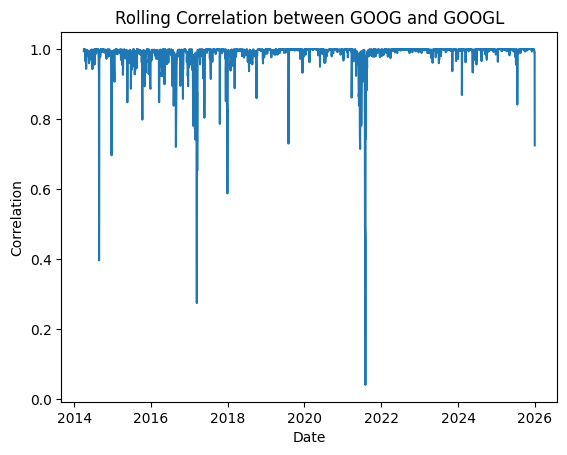

In [5]:
correl = rolling_correl(X,Y,5)
plt.plot(correl)
plt.title('Rolling Correlation between GOOG and GOOGL')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.show()

# Cointegration test

### 1- Engle-Granger two step procedure

$H_0$: no cointegration (residual has unit root)

$H_1$: cointegration (residual is stationary)

a) OLS regression to estimate the residuals
$$y_t = \alpha + \beta X_t + u_t$$

b) Check the stationarity of the residuals


In [6]:
def estimate_residual(X, Y):
    X = sm.add_constant(X)
    model = sm.OLS(Y, X)
    results = model.fit()
    residuals = results.resid
    beta = results.params.iloc[1]  
    return residuals, beta
    
# coint fait tout d'un coup donc mieux
def stationarity_resid(resid):
    result = adfuller(resid)
    stat_adf = result[0]
    pvalue= result[1]
    print("stat ADF:", stat_adf)
    print("p-value:", pvalue)
    return stat_adf, pvalue

def stationarity_resid1(X,Y):
    result = coint(X, Y) 
    return result

result = stationarity_resid1(X,Y)
pvalue = round(result[1],4)
pvalue

np.float64(0.0123)

# Estimate and plot the spread
$$\hat s_t = y_t - \alpha - \hat \beta X_t$$

stat ADF: -3.835918045068445
p-value: 0.0025604799519408808
Beta = 1.0124849321119198


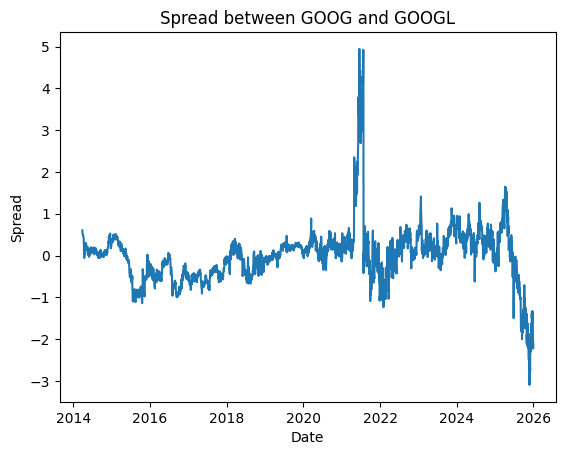

In [7]:
def estimate_spread(X,Y):
    resid, beta = estimate_residual(X,Y)
    stat_adf, pvalue = stationarity_resid(resid)
    return resid, stat_adf, pvalue, beta
spread = estimate_spread(X,Y)
beta = spread[3]
print("Beta =", beta)
plt.plot(spread[0])
plt.title('Spread between GOOG and GOOGL')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.show()

### Estimate the half life

$$s_t = \phi s_{t-1} + \epsilon _t$$


$$t_{1/2} = \frac{ln(2)}{-ln(\phi)} $$

Half life: durée moyenne necessaire pour que le spread revienne à la moitié de sa valeur de LT

In [8]:
spread = pd.DataFrame(spread[0], columns=['Spread'])

In [9]:
def estimate_half_life(spread):
    spread = spread.dropna()
    lag = spread.shift(1).dropna()
    model = sm.OLS(spread[1:],lag)
    results = model.fit()
    half_life = - np.log(2) / np.log(results.params[0])
    half_life = round(half_life, 2)
    return half_life

half_life = estimate_half_life(spread)
half_life

C:\Users\33607\AppData\Local\Temp\ipykernel_4356\3599589408.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  half_life = - np.log(2) / np.log(results.params[0])


np.float64(20.8)

# Design the trading strategy


**a) The intuition:**

If $\hat s_t > 0$ : short $y$, long $\hat \beta x$

else if $\hat s_t < 0$ : long $y$, short $\hat \beta x$


**b) Setting a threshold for $s_t$ :**

$$
z_t = \frac{s_t - \mu}{\sigma}
$$

$z_t > 2$ : Short $y$, Long $\hat \beta x$

$z_t < -2$ : Long $y$, Short $\hat \beta x$

**c) Exit rule :**

Exit trade if $|z_t| < 0.5$

**d) Risk management:**

Exit trade if holding period $> 2 \times \text{half life}$

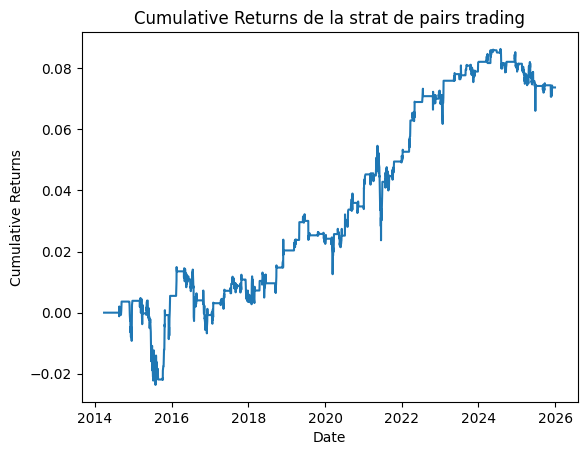

In [10]:
def strategie(spread, half_life, threshold, window):
    z = (spread - spread.rolling(window=window).mean()) / spread.rolling(window=window).std()
    signal = [0]  # pas de position au debut
    debut_trade = 0

    for i in range(1, len(z)):
        pos = signal[-1]
        if pos != 0 and (i - debut_trade) > 2 * half_life:  # risk management
            signal.append(0)
        elif pos != 0 and abs(z.iloc[i]) < 0.5:  # sortie
            signal.append(0)
        elif z.iloc[i] > threshold:  # short y, long beta*x
            signal.append(-1)
            if pos != -1:
                debut_trade = i
        elif z.iloc[i] < -threshold:  # long y, short beta*x
            signal.append(1)
            if pos != 1:
                debut_trade = i
        else:  # hold
            signal.append(pos)
    signal = pd.Series(signal, index=spread.index)
    return signal.shift(1)


def backtest(X, Y, signal, beta):
    returns_X = X.pct_change().shift(-1)
    returns_Y = Y.pct_change().shift(-1)
    signal = pd.Series(signal, index=returns_Y.index)
    strategy_returns = signal * (returns_Y - beta * returns_X)
    cumulative_returns =  (1 + strategy_returns).cumprod() - 1
    return cumulative_returns

signal = strategie(spread['Spread'], half_life, 2, int(2*half_life))
cumulative_returns = backtest(X, Y, signal, beta)
plt.plot(cumulative_returns)
plt.title('Cumulative Returns de la strat de pairs trading')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.show()

In [11]:
returns_X_s = X.pct_change().shift(-1)
returns_Y = Y.pct_change().shift(-1)
returns_X = X.pct_change()
returns_Y_s = Y.pct_change()

returns_X
returns_X_s
returns_X
X

2014-03-27     27.884
2014-03-28     28.031
2014-03-31     27.890
2014-04-01     28.400
2014-04-02     28.405
               ...   
2025-12-24    314.090
2025-12-26    313.510
2025-12-29    313.560
2025-12-30    313.850
2025-12-31    313.000
Name: GOOGL, Length: 2960, dtype: float64

# Rolling beta

In [12]:
def rolling_beta(X, Y, window):
    rolling_beta = (Y.rolling(window).cov(X) / X.rolling(window).var()).dropna()

    return rolling_beta

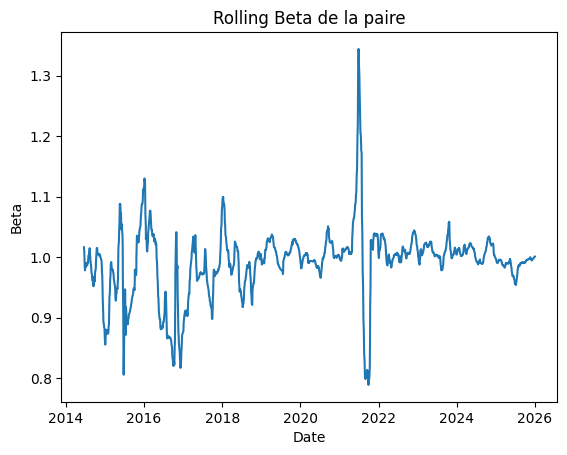

In [13]:
roll_beta = rolling_beta(X, Y, 60)
plt.plot(roll_beta)
plt.title('Rolling Beta de la paire')
plt.xlabel('Date')
plt.ylabel('Beta')
plt.show()

# Rolling spread

In [14]:
def rolling_spread(X, Y, window):
    resid = Y - rolling_beta(X, Y, window) * X
    return resid

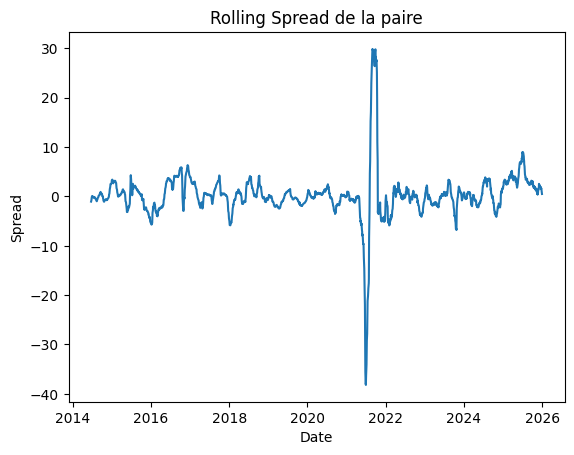

In [15]:
spread_roll = rolling_spread(X, Y, 60)
plt.plot(spread_roll)
plt.title('Rolling Spread de la paire')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.show()